# Additive Noise Mechanisms

This notebook documents the variations on additive noise mechanisms in OpenDP:

* Distribution: Laplace vs. Gaussian
* Support: float vs. integer
* Domain: scalar vs. vector
* Arithmetic: standard vs. modular
* Bit-depth

----
Any constructors that have not completed the proof-writing and vetting process may still be accessed if you opt-in to "contrib".
Please contact us if you are interested in proof-writing. Thank you!

In [1]:
import opendp.prelude as dp
dp.enable_features("contrib")

## Distribution: Laplace vs. Gaussian

The Laplace mechanism is used to privatize an aggregate, like a sum or mean.

An instance of the Laplace mechanism is captured by a _measurement_ containing the following five elements:

<details>
  <summary>Elements of a Laplace Measurement</summary>

1. We first define the **function** $f(\cdot)$, that applies the Laplace mechanism to some argument $x$. This function simply samples from the Laplace distribution centered at $x$, with a fixed noise scale.

$$f(x) = Laplace(\mu=x, b=scale)$$

2. Importantly, $f(\cdot)$ is only well-defined for any finite float input. This set of permitted inputs is described by the **input domain** (denoted `AtomDomain<f64>`).

3. The Laplace mechanism has a privacy guarantee in terms of epsilon. 
This guarantee is represented by a **privacy map**, a function that computes the privacy loss $\epsilon$ for any choice of sensitivity $\Delta$.

$$map(\Delta) = \Delta / scale <= \epsilon$$

4. This map only promises that the privacy loss will be at most $\epsilon$ if inputs from any two neighboring datasets may differ by no more than some quantity $\Delta$ under the absolute distance **input metric** (`AbsoluteDistance<f64>`).

5. We similarly describe units on the output ($\epsilon$) via the **output measure** (`MaxDivergence`).
</details>


The `make_laplace` constructor function returns the equivalent of the Laplace measurement described above.

In [2]:
# call the constructor to produce the measurement `base_lap`
input_space = dp.atom_domain(T=float, nan=False), dp.absolute_distance(T=float)
base_lap = dp.m.make_laplace(*input_space, scale=2.)

# invoke the measurement on some aggregate x, to sample Laplace(x, 1.) noise
aggregated = 0.
print("noisy aggregate:", base_lap(aggregated))

# we must know the sensitivity of `aggregated` to determine epsilon
sensitivity = 1.
print("epsilon:", base_lap.map(d_in=sensitivity))

noisy aggregate: -1.944494140529652
epsilon: 0.5


The analogous constructor for gaussian noise is `make_gaussian`: 

In [3]:
# call the constructor to produce the measurement `gauss`
input_space = dp.atom_domain(T=float, nan=False), dp.absolute_distance(T=float)
gauss = dp.m.make_gaussian(*input_space, scale=2.)

# invoke the measurement on some aggregate x, to sample Gaussian(x, 1.) noise
aggregated = 0.
print("noisy aggregate:", gauss(aggregated))

# we must know the sensitivity of `aggregated` to determine epsilon
sensitivity = 1.
print("rho:", gauss.map(d_in=sensitivity))

noisy aggregate: -1.1915364158207267
rho: 0.125


Notice that `base_lap` measures privacy with epsilon (in the `MaxDivergence` measure), and `base_gauss` measures privacy with rho (in the `ZeroConcentratedDivergence` measure).


## Support: Float vs. Integer

There are also discrete analogues of the continuous Laplace and Gaussian measurements.
The continuous measurements accept and emit floats, while the discrete measurements accept and emit integers.
Measurements with distributions supported on the integers expect integer sensitivities by default.

`make_laplace` on a discrete support is equivalent to the geometric mechanism:

In [4]:
# call the constructor to produce the measurement `base_discrete_lap`
input_space = dp.atom_domain(T=int), dp.absolute_distance(T=int)
base_discrete_lap = dp.m.make_laplace(*input_space, scale=1.)

# invoke the measurement on some integer aggregate x, to sample DiscreteLaplace(x, 1.) noise
aggregated = 0
print("noisy aggregate:", base_discrete_lap(aggregated))

# in this case, the sensitivity is integral:
sensitivity = 1
print("epsilon:", base_discrete_lap.map(d_in=sensitivity))

noisy aggregate: 0
epsilon: 1.0


`make_gaussian` on a discrete support is the analogous measurement for Gaussian noise:

In [5]:
# call the constructor to produce the measurement `base_discrete_gauss`
input_space = dp.atom_domain(T=int), dp.absolute_distance(T=int)
base_discrete_gauss = dp.m.make_gaussian(*input_space, scale=1.)

# invoke the measurement on some aggregate x, to sample DiscreteGaussian(x, 1.) noise
aggregated = 0
print("noisy aggregate:", base_discrete_gauss(aggregated))

# we must know the sensitivity of `aggregated` to determine epsilon
sensitivity = 1
print("rho:", base_discrete_gauss.map(d_in=sensitivity))

noisy aggregate: 0
rho: 0.5


The continuous mechanisms use these discrete samplers internally.
More information on this can be found at the end of this notebook.

## Domain: Scalar vs. Vector

Measurements covered thus far have accepted scalar inputs and emitted scalar outputs, 
and sensitivities have been expressed in terms of the absolute distance.

The noise addition mechanisms can similarly operate over metric spaces consisting of vectors, 
and where the distance between any two vectors is computed via the L1 or L2 distance.

In [6]:
# call again, but this time indicate that the measurement should operate over a vector domain
input_space = dp.vector_domain(dp.atom_domain(T=float, nan=False)), dp.l1_distance(T=float)
base_lap_vec = dp.m.make_laplace(*input_space, scale=1.)

aggregated = 1.
# If we try to pass the wrong data type into our vector laplace measurement, 
# the error shows that our float argument should be a vector of floats.
try:
    print("noisy aggregate:", base_lap_vec(aggregated))
except TypeError as e:
    # The error messages will often point to a discussion page with more info.
    print(e)

Expected type is Vec<f64> but input data is not a list.


In [7]:
# actually pass a vector-valued input, as expected
aggregated = [0., 2., 2.]
print("noisy aggregate:", base_lap_vec(aggregated))


noisy aggregate: [-1.8602899476342256, 1.9437219796134588, 2.4066711073468676]


The resulting measurement expects sensitivity in terms of the appropriate Lp-distance: the vector Laplace measurement expects sensitivity in terms of an `"l1_distance(T=f64)"`, while the vector Gaussian measurement expects a sensitivity in terms of an `"l2_distance(T=f64)"`. 

In [8]:
sensitivity = 1.
print("epsilon:", base_lap_vec.map(d_in=sensitivity))

epsilon: 1.0


The documentation for each constructor also reflects the relationship between `D` and the resulting input metric in a table:

In [9]:
print('\n'.join(line for line in dp.m.make_laplace.__doc__.splitlines() if line.startswith('|')))

| `input_domain`                  | input type   | `input_metric`         |
| ------------------------------- | ------------ | ---------------------- |
| `atom_domain(T)` (default)      | `T`          | `absolute_distance(T)` |
| `vector_domain(atom_domain(T))` | `Vec<T>`     | `l1_distance(T)`       |


The discrete Gaussian mechanism allows for the type of the input sensitivity to be a float.
This is because there is often a square root in the sensitivity calculations for vector-valued queries.

In [10]:
# call again, but this time indicate that the measurement should operate over a vector domain
input_space = dp.vector_domain(dp.atom_domain(T=int)), dp.l2_distance(T=float)
base_gauss_vec = dp.m.make_gaussian(*input_space, scale=1.)

base_gauss_vec.map(d_in=1.414)


0.999698

## Arithmetic: Standard vs. Modular

For integer-valued queries on cyclic domains, you may want additive noise to wrap around the native integer representation instead of living on the integers.
Set `modular=True` on `absolute_distance`, `l1_distance`, or `l2_distance` to enable wrapped Laplace or Gaussian noise on integer domains.

For example, `dp.absolute_distance(T=int, modular=True)` uses modular distance on the native `i32` representation in Python, so the mechanism operates modulo `2^32`.
This is useful when the released statistic already lives in a ring, such as a fixed-width counter.

In [11]:
# wrapped scalar Laplace on the native i32 ring
input_space = dp.atom_domain(T=int), dp.absolute_distance(T=int, modular=True)
modular_lap = dp.m.make_laplace(*input_space, scale=1.)
print(modular_lap)

# wrapped vector Gaussian on the same ring
input_space = dp.vector_domain(dp.atom_domain(T=int)), dp.l2_distance(T=float, modular=True)
modular_gauss = dp.m.make_gaussian(*input_space, scale=2.)
print("rho:", modular_gauss.map(d_in=1.))


Measurement(
    input_domain   = AtomDomain(T=i32),
    input_metric   = AbsoluteDistance(i32, modulo),
    output_measure = MaxDivergence)
rho: 0.125


The privacy map under modular arithmetic matches standard arithmetic.

## Bit depth

By default, all floating-point data types default to 64-bit double-precision (denoted `"f64"`), and all integral data types default to 32-bit (denoted `"i32"`).
The atomic data type expected by the function and privacy units can be further configured to operate over specific bit-depths by explicitly specifying `"f32"` instead of `"float"`, or `"i64"` instead of `"int"`. 

More information on acceptable data types can be found in the _Utilities > Typing_ section of the User Guide.

## Desideratum: Floating-Point Granularity

The "continuous" Laplace and Gaussian measurements convert their float arguments to a rational representation, and then add integer noise to the numerator via the respective discrete distribution. 
In the OpenDP Library's default configuration, this rational representation of a float is exact.
Therefore the privacy analysis is as tight as if you were to sample truly continuous noise and then postprocess by rounding to the nearest float. 

For most use-cases the sampling algorithm is sufficiently fast when the rational representation is exact.
That is, when noise is sampled with a granularity of $2^{-1074}$, the same granularity as the distance between subnormal 64-bit floats.
However, the granularity can be adjusted to $2^k$, for some choice of k, for a faster runtime.
Adjusting this parameter comes with a small penalty to the sensitivity (to account for rounding to the nearest rational), and subsequently, to the privacy parameters.

The following plot shows the resulting distribution for some large choices of k:

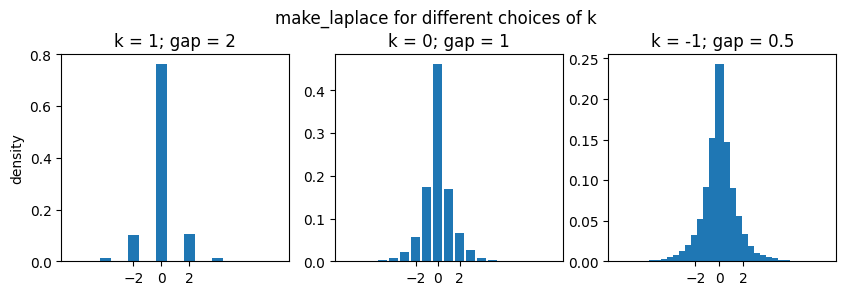

In [12]:
import numpy as np
import matplotlib.pyplot as plt
num_samples = 10_000
space = dp.vector_domain(dp.atom_domain(T=float, nan=False), num_samples), dp.l1_distance(T=float)

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(10, 3))
fig.subplots_adjust(top=0.8)
for axis, k in zip(axes, [1, 0, -1]):
    base_lap_vec = dp.m.make_laplace(*space, scale=1., k=k)
    support, counts = np.unique(base_lap_vec([0.] * num_samples), return_counts=True)
    axis.bar(support, counts / num_samples)
    axis.set_xticks([-2, 0, 2])
    axis.set_title(f"k = {k}; gap = {2**k}")
axes[0].set_ylabel("density")
fig.suptitle('make_laplace for different choices of k', y=0.95);

The distribution becomes increasingly smooth as k approaches the default value (`-1074`).

The privacy map still adds a penalization when the sensitivity is zero. 
The following table uses this behavior to show the increase in epsilon for some choices of k:

In [13]:
k = [-1074, -1073, -100, -1, 0, 1]
space = dp.atom_domain(T=float, nan=False), dp.absolute_distance(T=float)
ε_penalty = [dp.m.make_laplace(*space, scale=1., k=k_i).map(d_in=0.) for k_i in k]
detail = ["no penalty", "~min float", "~2^-100", "~2^-1", "~2^0", "~2^1"]

import pandas as pd
pd.DataFrame({"k": k, "ε penalty": ε_penalty, "detail": detail}).set_index("k")

,ε penalty,detail
k,,
-1074,0.000000e+00,no penalty
-1073,4.940656e-324,~min float
-100,7.888609e-31,~2^-100
-1,5.000000e-01,~2^-1
0,1.000000e+00,~2^0
1,2.000000e+00,~2^1
